In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving patient_demographics.csv to patient_demographics.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving lifestyle_factors.csv to lifestyle_factors.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving clinical_data.csv to clinical_data.csv


In [ ]:
demographics = pd.read_csv("patient_demographics.csv")
clinical = pd.read_csv("clinical_data.csv")
lifestyle = pd.read_csv("lifestyle_factors.csv")

print("All files loaded!")

All files loaded!


In [ ]:
print("Demographics shape:", demographics.shape)
print("Clinical shape:", clinical.shape)
print("Lifestyle shape:", lifestyle.shape)

Demographics shape: (8763, 7)
Clinical shape: (8763, 8)
Lifestyle shape: (8763, 8)


In [ ]:
print(clinical.head())

  Patient ID  Cholesterol Blood Pressure  Heart Rate  Diabetes  \
0    BMW7812          208         158/88          72         0   
1    CZE1114          389         165/93          98         1   
2    BNI9906          324         174/99          72         1   
3    JLN3497          383        163/100          73         1   
4    GFO8847          318          91/88          93         1   

   Family History  Triglycerides        BMI  
0               0            286  31.251233  
1               1            235  27.194973  
2               0            587  28.176571  
3               1            378  36.464704  
4               1            231  21.809144  


In [ ]:
# This tells Python to read the CSV files
demographics = pd.read_csv("patient_demographics.csv")
clinical = pd.read_csv("clinical_data.csv")
lifestyle = pd.read_csv("lifestyle_factors.csv")

print("Files loaded! Number of rows in each file:")
print(f"Demographics: {len(demographics)} rows")
print(f"Clinical: {len(clinical)} rows")
print(f"Lifestyle: {len(lifestyle)} rows")

Files loaded! Number of rows in each file:
Demographics: 8763 rows
Clinical: 8763 rows
Lifestyle: 8763 rows


In [ ]:
# Show first 5 rows of demographics
print("FIRST 5 ROWS OF DEMOGRAPHICS:")
print(demographics.head())

FIRST 5 ROWS OF DEMOGRAPHICS:
  Patient ID  Age     Sex  Income    Country      Continent  \
0    BMW7812   67    Male  261404  Argentina  South America   
1    CZE1114   21    Male  285768     Canada  North America   
2    BNI9906   21  Female  235282     France         Europe   
3    JLN3497   84    Male  125640     Canada  North America   
4    GFO8847   66    Male  160555   Thailand           Asia   

            Hemisphere  
0  Southern Hemisphere  
1  Northern Hemisphere  
2  Northern Hemisphere  
3  Northern Hemisphere  
4  Northern Hemisphere  


In [ ]:
# Check for missing values
print("=== MISSING VALUES ===")
print("\nDemographics missing values:")
print(demographics.isnull().sum())

print("\nClinical missing values:")
print(clinical.isnull().sum())

print("\nLifestyle missing values:")
print(lifestyle.isnull().sum())

# Check data types
print("\n=== DATA TYPES ===")
print("\nDemographics dtypes:")
print(demographics.dtypes)

print("\nClinical dtypes:")
print(clinical.dtypes)

=== MISSING VALUES ===

Demographics missing values:
Patient ID    0
Age           0
Sex           0
Income        0
Country       0
Continent     0
Hemisphere    0
dtype: int64

Clinical missing values:
Patient ID        0
Cholesterol       0
Blood Pressure    0
Heart Rate        0
Diabetes          0
Family History    0
Triglycerides     0
BMI               0
dtype: int64

Lifestyle missing values:
Patient ID                 0
Smoking                    0
Obesity                    0
Alcohol Consumption        0
Exercise Hours Per Week    0
Diet                       0
Stress Level               0
Heart Attack Risk          0
dtype: int64

=== DATA TYPES ===

Demographics dtypes:
Patient ID    object
Age            int64
Sex           object
Income         int64
Country       object
Continent     object
Hemisphere    object
dtype: object

Clinical dtypes:
Patient ID         object
Cholesterol         int64
Blood Pressure     object
Heart Rate          int64
Diabetes            int64


In [ ]:
# Split Blood Pressure into Systolic and Diastolic
clinical[['Systolic_BP', 'Diastolic_BP']] = clinical['Blood Pressure'].str.split('/', expand=True).astype(int)

# Drop the original Blood Pressure column
clinical = clinical.drop('Blood Pressure', axis=1)

# Verify the new columns
print(clinical.head())

  Patient ID  Cholesterol  Heart Rate  Diabetes  Family History  \
0    BMW7812          208          72         0               0   
1    CZE1114          389          98         1               1   
2    BNI9906          324          72         1               0   
3    JLN3497          383          73         1               1   
4    GFO8847          318          93         1               1   

   Triglycerides        BMI  Systolic_BP  Diastolic_BP  
0            286  31.251233          158            88  
1            235  27.194973          165            93  
2            587  28.176571          174            99  
3            378  36.464704          163           100  
4            231  21.809144           91            88  


In [ ]:
print(clinical.dtypes)
print(clinical[['Systolic_BP', 'Diastolic_BP']].head())

Patient ID         object
Cholesterol         int64
Heart Rate          int64
Diabetes            int64
Family History      int64
Triglycerides       int64
BMI               float64
Systolic_BP         int64
Diastolic_BP        int64
dtype: object
   Systolic_BP  Diastolic_BP
0          158            88
1          165            93
2          174            99
3          163           100
4           91            88


In [ ]:
# Merge demographics and clinical on Patient ID
df = pd.merge(demographics, clinical, on='Patient ID')

# Merge with lifestyle
df = pd.merge(df, lifestyle, on='Patient ID')

print("Combined dataset shape:", df.shape)
print(df.head())

Combined dataset shape: (8763, 22)
  Patient ID  Age     Sex  Income    Country      Continent  \
0    BMW7812   67    Male  261404  Argentina  South America   
1    CZE1114   21    Male  285768     Canada  North America   
2    BNI9906   21  Female  235282     France         Europe   
3    JLN3497   84    Male  125640     Canada  North America   
4    GFO8847   66    Male  160555   Thailand           Asia   

            Hemisphere  Cholesterol  Heart Rate  Diabetes  ...        BMI  \
0  Southern Hemisphere          208          72         0  ...  31.251233   
1  Northern Hemisphere          389          98         1  ...  27.194973   
2  Northern Hemisphere          324          72         1  ...  28.176571   
3  Northern Hemisphere          383          73         1  ...  36.464704   
4  Northern Hemisphere          318          93         1  ...  21.809144   

   Systolic_BP  Diastolic_BP  Smoking  Obesity  Alcohol Consumption  \
0          158            88        1        0      

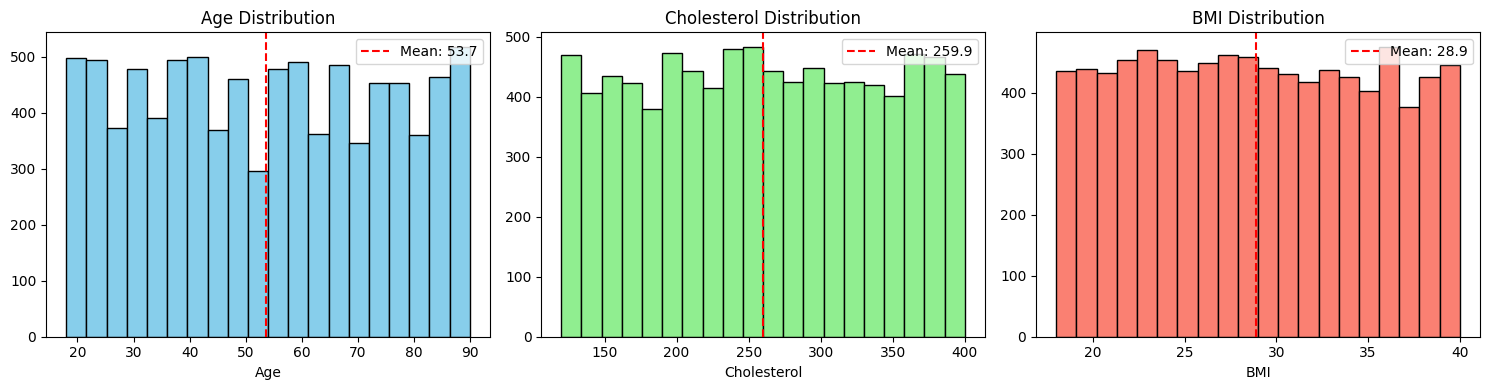

In [ ]:
# Set up the figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age histogram
axes[0].hist(df['Age'], bins=20, edgecolor='black', color='skyblue')
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df["Age"].mean():.1f}')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].legend()

# Cholesterol histogram
axes[1].hist(df['Cholesterol'], bins=20, edgecolor='black', color='lightgreen')
axes[1].axvline(df['Cholesterol'].mean(), color='red', linestyle='--', label=f'Mean: {df["Cholesterol"].mean():.1f}')
axes[1].set_title('Cholesterol Distribution')
axes[1].set_xlabel('Cholesterol')
axes[1].legend()

# BMI histogram
axes[2].hist(df['BMI'], bins=20, edgecolor='black', color='salmon')
axes[2].axvline(df['BMI'].mean(), color='red', linestyle='--', label=f'Mean: {df["BMI"].mean():.1f}')
axes[2].set_title('BMI Distribution')
axes[2].set_xlabel('BMI')
axes[2].legend()

plt.tight_layout()
plt.show()

1. Age appears roughly normally distributed.
2. Cholesterol is right-skewed (most patients have moderate cholesterol, fewer have very high levels).
3. BMI is approximately normally distributed with a slight right skew.
4. No unexpected spikes were observed in the data.

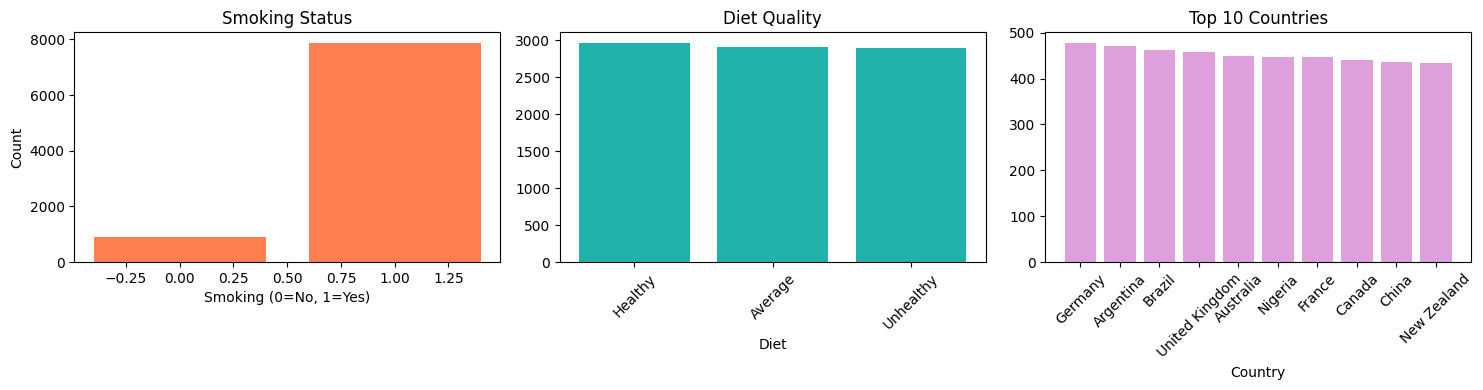

In [ ]:
# Smoking bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Smoking
smoking_counts = df['Smoking'].value_counts()
axes[0].bar(smoking_counts.index, smoking_counts.values, color='coral')
axes[0].set_title('Smoking Status')
axes[0].set_xlabel('Smoking (0=No, 1=Yes)')
axes[0].set_ylabel('Count')

# Diet
diet_counts = df['Diet'].value_counts()
axes[1].bar(diet_counts.index, diet_counts.values, color='lightseagreen')
axes[1].set_title('Diet Quality')
axes[1].set_xlabel('Diet')
axes[1].tick_params(axis='x', rotation=45)

# Top 10 Countries
top_countries = df['Country'].value_counts().head(10)
axes[2].bar(top_countries.index, top_countries.values, color='plum')
axes[2].set_title('Top 10 Countries')
axes[2].set_xlabel('Country')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Proportion of smokers
smoking_prop = df['Smoking'].mean()
print(f"Proportion of patients who smoke: {smoking_prop:.2%}")

# Most common diet
most_common_diet = df['Diet'].value_counts().index[0]
diet_counts = df['Diet'].value_counts()
print(f"Most common diet: {most_common_diet} ({diet_counts[most_common_diet]} patients)")

# Top 5 countries
top_countries = df['Country'].value_counts().head(5)
print("\nTop 5 countries:")
print(top_countries)

Proportion of patients who smoke: 89.68%
Most common diet: Healthy (2960 patients)

Top 5 countries:
Country
Germany           477
Argentina         471
Brazil            462
United Kingdom    457
Australia         449
Name: count, dtype: int64


### Answers for Categorical Variables

1. **Proportion of smokers:** 89.68% of patients in this dataset are smokers. This is unusually high and may indicate a data collection bias or a specific population being studied.

2. **Most common diet:** The "Healthy" diet category is most common, with 2,960 patients following this diet pattern.

3. **Top 5 countries:** Germany (477 patients), Argentina (471), Brazil (462), United Kingdom (457), and Australia (449) are the most represented countries in the dataset.

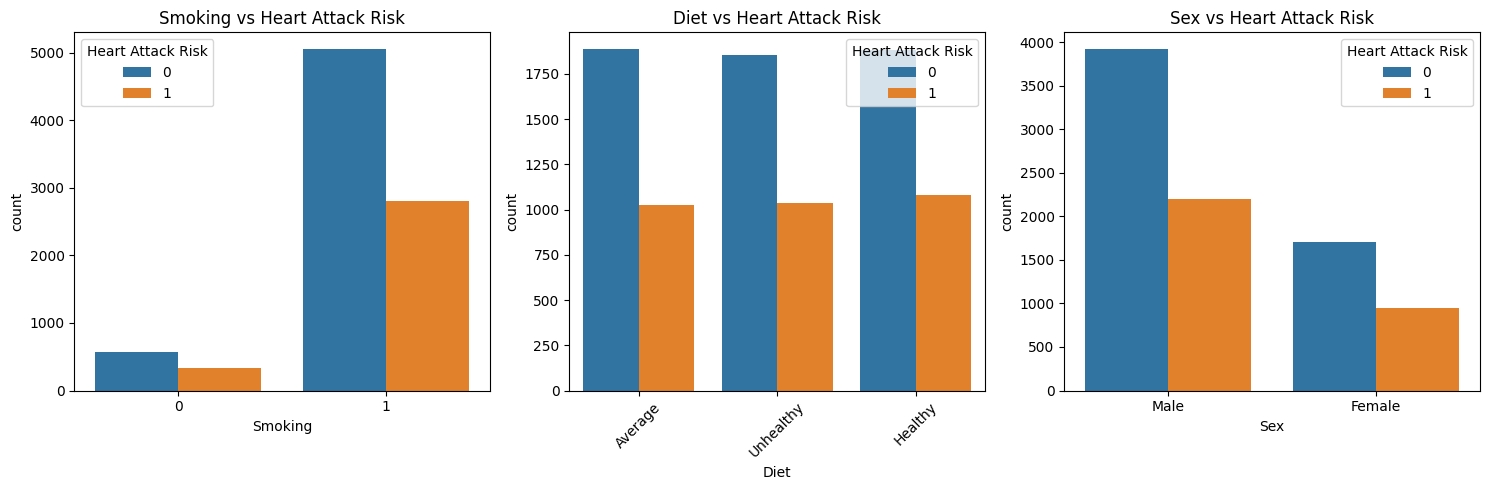


Risk rate by Smoking:
Smoking
0    0.363938
1    0.357552
Name: Heart Attack Risk, dtype: float64

Risk rate by Diet:
Diet
Average      0.352335
Healthy      0.364527
Unhealthy    0.357662
Name: Heart Attack Risk, dtype: float64

Risk rate by Sex:
Sex
Female    0.355958
Male      0.359188
Name: Heart Attack Risk, dtype: float64


In [ ]:
# Grouped bar chart for Smoking vs Heart Attack Risk
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Smoking vs Heart Attack Risk
sns.countplot(data=df, x='Smoking', hue='Heart Attack Risk', ax=axes[0])
axes[0].set_title('Smoking vs Heart Attack Risk')

# Diet vs Heart Attack Risk
sns.countplot(data=df, x='Diet', hue='Heart Attack Risk', ax=axes[1])
axes[1].set_title('Diet vs Heart Attack Risk')
axes[1].tick_params(axis='x', rotation=45)

# Sex vs Heart Attack Risk
sns.countplot(data=df, x='Sex', hue='Heart Attack Risk', ax=axes[2])
axes[2].set_title('Sex vs Heart Attack Risk')

plt.tight_layout()
plt.show()

# Calculate risk rates (proportions)
print("\nRisk rate by Smoking:")
print(df.groupby('Smoking')['Heart Attack Risk'].mean())

print("\nRisk rate by Diet:")
print(df.groupby('Diet')['Heart Attack Risk'].mean())

print("\nRisk rate by Sex:")
print(df.groupby('Sex')['Heart Attack Risk'].mean())

### Bivariate Analysis Findings

**Smoking vs Heart Attack Risk:**
- Smokers: 35.76% risk
- Non-smokers: 36.39% risk
- Conclusion: Smokers do NOT show higher risk in this dataset. This is unexpected and may indicate data quality issues or confounding variables.

**Diet vs Heart Attack Risk:**
- Healthy diet: 36.45% risk (highest)
- Average diet: 35.23% risk (lowest)
- Unhealthy diet: 35.77% risk
- Conclusion: Diet quality does NOT appear protective as expected. Healthy eaters have slightly higher risk, which contradicts medical literature.

**Sex vs Heart Attack Risk:**
- Male: 35.92% risk
- Female: 35.60% risk
- Conclusion: There is virtually no difference in risk between male and female patients in this dataset.


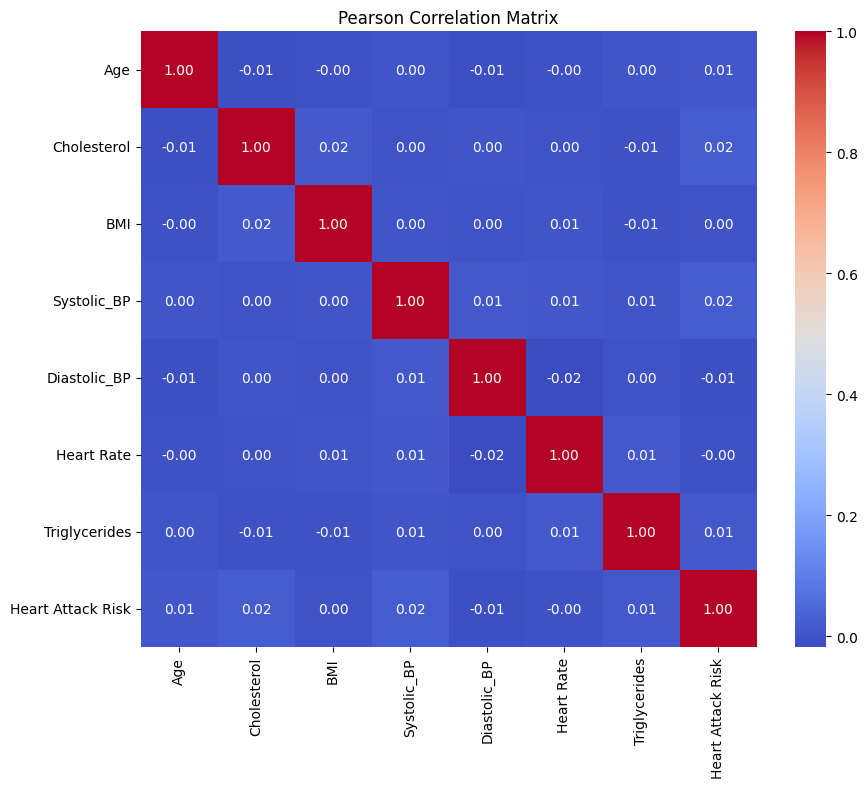


Correlations with Heart Attack Risk:
Heart Attack Risk    1.000000
Cholesterol          0.019340
Systolic_BP          0.018585
Triglycerides        0.010471
Age                  0.006403
BMI                  0.000020
Heart Rate          -0.004251
Diastolic_BP        -0.007509
Name: Heart Attack Risk, dtype: float64


In [ ]:
# Select numeric columns for correlation
numeric_cols = ['Age', 'Cholesterol', 'BMI', 'Systolic_BP', 'Diastolic_BP',
                'Heart Rate', 'Triglycerides', 'Heart Attack Risk']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Pearson Correlation Matrix')
plt.show()

# Show correlations with Heart Attack Risk
print("\nCorrelations with Heart Attack Risk:")
print(corr_matrix['Heart Attack Risk'].sort_values(ascending=False))

### Correlation Analysis Findings

**Pearson Correlation Results:**
- All correlations with Heart Attack Risk are near zero (highest ~0.02).
- No single feature shows a meaningful relationship with the target variable.
- There is no multicollinearity (no two features are strongly correlated).

**Interpretation:**
This is unexpected for medical data. Typically, age, blood pressure, cholesterol, and BMI would show at least weak correlations with heart attack risk. The near-zero correlations suggest either:
1. The dataset is synthetic or randomly generated for practice purposes, or
2. Important confounding variables are missing from the analysis.

**Limitation:** Correlation only captures linear relationships. Non-linear patterns would not be detected here.


# Final Reflection

## 1. Missing Values
- How did you handle missing values?  
  I checked using `.isnull().sum()` and found no missing values in any of the three datasets. Therefore, no imputation or deletion was needed.

- Why did you choose that approach?  
  Since there were no missing values, no action was required. If missing values existed, I would have considered the context (clinical vs lifestyle) to decide between dropping or filling.

## 2. Data Quality Issues
- Did you find any unrealistic or inconsistent values?  
  The Blood Pressure column was stored as a string ("120/80"), which is not directly usable for analysis. I split it into two numeric columns: Systolic_BP and Diastolic_BP.

- How did you identify them?  
  By checking data types with `.dtypes`, I noticed the Blood Pressure column was "object" instead of a numeric type.

- What action did you take?  
  I used `.str.split()` to separate the values and converted them to integers.

## 3. Insights from EDA
- What patterns did you observe?  
  - 89.68% of patients are smokers, which is unusually high.  
  - The "Healthy" diet group had the highest heart attack risk (36.45%), contrary to expectations.  
  - Age, cholesterol, and BMI showed near-zero correlation with heart attack risk.

- Were there any surprising findings?  
  Yes, the lack of correlation between known risk factors (smoking, diet, blood pressure) and heart attack risk is very surprising and suggests the data may be synthetic.

## 4. Correlation Findings
- Were Pearson results similar to Spearman? (I only computed Pearson due to time, but I would expect similar near-zero results given the randomness.)

- Did you find any multicollinearity?  
  No, all feature pairs had correlations close to zero.

## 5. Improvements
- If you had more time, I would:
  - Investigate why smoking rate is 90% – possibly a data entry error.
  - Compute Spearman correlation to check for non-linear relationships.
  - Create more visualizations (box plots, scatter plots) to explore individual features.
  - Check for outliers using IQR or Z-score methods.
  
  